## Moran model

This script performs simulations of transitions of a system of redundant duplicates towards one LOF, LOE, or LOA allele under a Moran model. It tests the rates obtained when using all sampled or only accessible LOF and LOA mutations. LOE mutation rates are taken from Urtecho, et al., 2023. eLife.


In [1]:
# Load libraries
import numpy as np
import pandas as pd
import datetime

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class Population_Moran:
    """
    Instantiate as example_pop = Population(N, murates, fitnesses) 
    where N is an integer and murates/fitnesses are tuples
    The indexes of the tuples are important and must be given like this:
        (muE, muA, muF, muFA, muFE, muAE)
        (wD, wE, wA, wF)
    The initial genotype D can mutate to 3 possible genotypes with rates mui
    The 3 mutants can mutate to another genotype with rates muij
    """
    def __init__(self, N, murates, fitnesses):
        """ 
        The initial population starts with the D genotype fixed
        The elements in murates are the mutations per genes per generation
        The elements in fitnesses is the relative fitnesses of the 4 genotypes 
        such that wD = 1 and wi = 1 + si where si is the selection coefficient
        which can be positive or negative
        """
        self.N = N
        self.murates = murates
        
        self.muE = murates[0]
        self.muA = murates[1]
        self.muF = murates[2]
        
        self.fitnesses = fitnesses
        self.pop = {'ND' : self.N, 'NE' : 0, 'NA' : 0, 'NF' : 0}
    
    def mutate(self):
        """
        The number of mutants in each generation is determined by sampling a 
        random number from a poisson distribution with mean equal to the
        mutation rate. Thus, mutation rates are mutations per gene per
        generation.
        
        The if conditions make sure we don't end up with negative individuals
        """
        #D that mutates to the other 3
        if self.pop['ND'] != 0:
            newE = np.random.poisson(self.murates[0], 1)
            if newE[0] > self.pop['ND']:
                newE[0] = self.pop['ND']
            self.pop['ND'] -= newE[0]
            self.pop['NE'] += newE[0]
        if self.pop['ND'] != 0:
            newA = np.random.poisson(self.murates[1], 1)
            if newA[0] > self.pop['ND']:
                newA[0] = self.pop['ND']
            self.pop['ND'] -= newA[0]
            self.pop['NA'] += newA[0]
        if self.pop['ND'] != 0:
            newF = np.random.poisson(self.murates[2], 1)
            if newF[0] > self.pop['ND']:
                newF[0] = self.pop['ND']
            self.pop['ND'] -= newF[0]
            self.pop['NF'] += newF[0]

        
    def driftsel(self):
        """
        This method applies the forces of drift and selection to the population
        Both forces are coupled in a multinomial sampling with probability values (pvals)
        given by the frequency of each genotype weighted by its fitness such that
        each genotype has probability (Ni/N)wi/sum((Ni/N)wi)
        """
        ## Vectors contain ND, NE, NA, NF in that order
        start_individuals = [self.pop['ND'], self.pop['NE'], self.pop['NA'], self.pop['NF']]
        
        frequencies = [ i / self.N for i in start_individuals ]
        unweighted_pvals = [self.fitnesses[i]*frequencies[i] for i in range(len(self.fitnesses))] 
        pvals = [unweighted/sum(unweighted_pvals) for unweighted in unweighted_pvals]
        
        ## Choose with the above frequencies an individual to be a parent
        new_individuals_orig = np.random.multinomial(1, pvals)
        
        ## Apply probabilities of mutation ##
        # Only mutate from the initial state to LOE, LOA, or LOF
        if new_individuals_orig[0] == 1:
            # Sample one element with probabilities muE, muA, muF, or (1 - muE - muA, muF) [no mutation]
            vector_probs = [1 - (self.muE + self.muA + self.muF), self.muE, self.muA, self.muF]
            new_individuals = np.random.multinomial(1, vector_probs)
        else:
            new_individuals = new_individuals_orig
        
        ## From the remaining N-1 individuals, choose one to die
        tmp_individuals = start_individuals - new_individuals_orig
        tmp_frequencies = [ i / (self.N - 1) for i in tmp_individuals ]
        
        dead_individuals = np.random.multinomial(1, tmp_frequencies)
        
        ## Update populations
        self.pop['ND'] = start_individuals[0] + new_individuals[0] - dead_individuals[0]
        self.pop['NE'] = start_individuals[1] + new_individuals[1] - dead_individuals[1]
        self.pop['NA'] = start_individuals[2] + new_individuals[2] - dead_individuals[2]
        self.pop['NF'] = start_individuals[3] + new_individuals[3] - dead_individuals[3]
    
    def evolve(self, g):
        """
        This will apply the rounds of mutations, drift, and selection g times,
        which represents the number of generations forward
        """
        for generation in range(g):
            self.driftsel()
            
    def freqTraj(self, nGen):
        """
        Plotting method to get the allele frequency trajectory 
        after nGen generations. In this project I focus on the D genotype decay
        but you can add arguments to plt.plot() to track any of the four alleles
        """
        x_axis = [i for i in range(nGen)]
        ND_history = [] 
        NE_history = []
        NA_history = []
        NF_history = []
    
        for generation_step in range(nGen):
            self.evolve(1)
            ND_history.append(self.pop['ND'])
            NE_history.append(self.pop['NE'])
            NA_history.append(self.pop['NA'])
            NF_history.append(self.pop['NF'])
        
        return(ND_history, NE_history, NA_history, NF_history)

## Sampled vs accessible

This part of the code uses the updated mutation rates. LOA corresponds to mutations that disrupt the dimerization interface by at least 2 kcal / mol.


In [3]:
## Define a function
def sims_moran_model(n_populations, n_individuals, pct_stop, murates, fitnesses_noint, fitnesses_int):
    '''
    A function that receives popoulation size, number of populations, 
    mutation rates, and fitness values to run simulations in a moran model.
    Simulations stop when the percentage of the population with the initial
    state drops below a given threshold.
    '''
    ## Simulations without interference ##
    nb_generations_noint =[] #it will store how many generations it took for each population

    populations = [Population_Moran(n_individuals, murates, fitnesses_noint) for i in range(n_populations)]

    for sample in populations:
        sample_generations = 0
        while sample.pop['ND'] > n_individuals*pct_stop:
            sample.evolve(1)
            sample_generations += 1
        nb_generations_noint.append(sample_generations)


    ## Run simulations with interference (Moran model)
    nb_generations_int =[] #it will store how many generations it took for each population

    populations = [Population_Moran(n_individuals, murates, fitnesses_int) for i in range(n_populations)]

    for sample in populations:
        sample_generations = 0
        while sample.pop['ND'] > n_individuals*pct_stop:
            sample.evolve(1)
            sample_generations += 1
        nb_generations_int.append(sample_generations)

    ## Plot together
    (n1, bins1, patches1) = plt.hist(nb_generations_int, bins = 50, alpha = 0.5, label = 'Interference')
    (n2, bins2, patches2) = plt.hist(nb_generations_noint, bins = bins1, alpha = 0.5, color = 'orangered', label = 'Neutral')

    plt.legend()
    plt.title("Distributions (Moran model)")
    plt.xlabel('Number of birth events before reaching 0.8N')
    plt.ylabel('Number of populations')
    
    return(nb_generations_int, nb_generations_noint)

When the loss of one copy is neutral

Sampled, loss of one copy is neutral, stop at 0.2N
------
Sampled, loss of one copy is neutral, stop at 0.5N
------
Sampled, loss of one copy is neutral, stop at 0.8N
------
Accessible, loss of one copy is neutral, stop at 0.2N
------
Accessible, loss of one copy is neutral, stop at 0.5N
------
Accessible, loss of one copy is neutral, stop at 0.8N
------


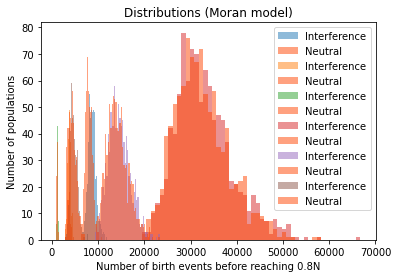

In [4]:
#### Initialize common variables for the different scenarios ####
n_individuals = 1000
n_populations = 1000

## Fitness values (initial, LOE, LOA, LOF)
fitnesses_noint = (1, 1, 1, 1)
fitnesses_int = (1, 1, 1, 0.36)

## Calculate the new murates (LOE, LOA, LOF)
murates = (0.0345, 0.1212, 0.0437)

### Sampled variants ###

## Loss of one copy is neutral ##

## Stop at 0.2N
pct_stop = 0.2
nb_generations_int_sam_neu_pct20, nb_generations_noint_sam_neu_pct20 = sims_moran_model(n_populations, n_individuals,
                                                            pct_stop, murates, fitnesses_noint,
                                                            fitnesses_int)

# Save the results
df_final = pd.DataFrame(zip(nb_generations_int_sam_neu_pct20, nb_generations_noint_sam_neu_pct20), 
                        columns = ['Num_events_int', 'Num_events_noint'])

df_final.to_csv('../../Data/Moran_model/Sampled/MoranModel_' + str(pct_stop) + 'pct_number_events_LOA_LOE_Neutral_Sampled.tsv',
                header = True, index = False, sep = '\t')

print('Sampled, loss of one copy is neutral, stop at 0.2N')
print('------')


## Stop at 0.5N
pct_stop = 0.5
nb_generations_int_sam_neu_pct50, nb_generations_noint_sam_neu_pct50 = sims_moran_model(n_populations, n_individuals,
                                                            pct_stop, murates, fitnesses_noint,
                                                            fitnesses_int)

# Save the results
df_final = pd.DataFrame(zip(nb_generations_int_sam_neu_pct50, nb_generations_noint_sam_neu_pct50), 
                        columns = ['Num_events_int', 'Num_events_noint'])

df_final.to_csv('../../Data/Moran_model/Sampled/MoranModel_' + str(pct_stop) + 'pct_number_events_LOA_LOE_Neutral_Sampled.tsv',
                header = True, index = False, sep = '\t')

print('Sampled, loss of one copy is neutral, stop at 0.5N')
print('------')


## Stop at 0.8N
pct_stop = 0.8
nb_generations_int_sam_neu_pct80, nb_generations_noint_sam_neu_pct80 = sims_moran_model(n_populations, n_individuals,
                                                            pct_stop, murates, fitnesses_noint,
                                                            fitnesses_int)

# Save the results
df_final = pd.DataFrame(zip(nb_generations_int_sam_neu_pct80, nb_generations_noint_sam_neu_pct80), 
                        columns = ['Num_events_int', 'Num_events_noint'])

df_final.to_csv('../../Data/Moran_model/Sampled/MoranModel_' + str(pct_stop) + 'pct_number_events_LOA_LOE_Neutral_Sampled.tsv',
                header = True, index = False, sep = '\t')

print('Sampled, loss of one copy is neutral, stop at 0.8N')
print('------')



### Accessible variants ###

## Fitness values (initial, LOE, LOA, LOF) ##
fitnesses_noint = (1, 1, 1, 1)
fitnesses_int = (1, 1, 1, 0.36)

## Calculate the new murates

murates = (0.0345, 0.0114, 0.0027)

## Loss of one copy is neutral ##

## Stop at 0.2N
pct_stop = 0.2
nb_generations_int_sam_neu_pct20, nb_generations_noint_sam_neu_pct20 = sims_moran_model(n_populations, n_individuals,
                                                            pct_stop, murates, fitnesses_noint,
                                                            fitnesses_int)

# Save the results
df_final = pd.DataFrame(zip(nb_generations_int_sam_neu_pct20, nb_generations_noint_sam_neu_pct20), 
                        columns = ['Num_events_int', 'Num_events_noint'])

df_final.to_csv('../../Data/Moran_model/Accessible/MoranModel_' + str(pct_stop) + 'pct_number_events_LOA_LOE_Neutral_Accessible.tsv',
                header = True, index = False, sep = '\t')

print('Accessible, loss of one copy is neutral, stop at 0.2N')
print('------')

## Stop at 0.5N
pct_stop = 0.5
nb_generations_int_sam_neu_pct50, nb_generations_noint_sam_neu_pct50 = sims_moran_model(n_populations, n_individuals,
                                                            pct_stop, murates, fitnesses_noint,
                                                            fitnesses_int)

# Save the results
df_final = pd.DataFrame(zip(nb_generations_int_sam_neu_pct50, nb_generations_noint_sam_neu_pct50), 
                        columns = ['Num_events_int', 'Num_events_noint'])

df_final.to_csv('../../Data/Moran_model/Accessible/MoranModel_' + str(pct_stop) + 'pct_number_events_LOA_LOE_Neutral_Accessible.tsv',
                header = True, index = False, sep = '\t')

print('Accessible, loss of one copy is neutral, stop at 0.5N')
print('------')

## Stop at 0.8N
pct_stop = 0.8
nb_generations_int_sam_neu_pct80, nb_generations_noint_sam_neu_pct80 = sims_moran_model(n_populations, n_individuals,
                                                            pct_stop, murates, fitnesses_noint,
                                                            fitnesses_int)

# Save the results
df_final = pd.DataFrame(zip(nb_generations_int_sam_neu_pct80, nb_generations_noint_sam_neu_pct80), 
                        columns = ['Num_events_int', 'Num_events_noint'])

df_final.to_csv('../../Data/Moran_model/Accessible/MoranModel_' + str(pct_stop) + 'pct_number_events_LOA_LOE_Neutral_Accessible.tsv',
                header = True, index = False, sep = '\t')

print('Accessible, loss of one copy is neutral, stop at 0.8N')
print('------')



